In [12]:
# ==============================================================================
# PHASES 1, 2 & 3: DATA INGESTION, CLEANING & PORTFOLIO SETUP
# ==============================================================================
import pandas as pd
import numpy as np
import yfinance as yf
from scipy import stats

# 1. Configuration & Tickers
tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM', 'AMZN', 'META', 'GOOGL', 'TSLA', 'UNH']
benchmark_ticker = '^GSPC'
start_date = '2015-01-01'
end_date = '2026-07-25'
INITIAL_PORTFOLIO_VALUE = 1000000  # $1,000,000 portfolio

print("--- PHASE 1: Downloading Data ---")
# Use auto_adjust=False to guarantee clean column handling
raw_data_tickers = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
raw_data_benchmark = yf.download(benchmark_ticker, start=start_date, end=end_date, auto_adjust=False)

# Extract prices safely
if 'Adj Close' in raw_data_tickers.columns:
    raw_prices = raw_data_tickers['Adj Close']
else:
    raw_prices = raw_data_tickers['Close']

if 'Adj Close' in raw_data_benchmark.columns:
    benchmark_prices = raw_data_benchmark['Adj Close']
else:
    benchmark_prices = raw_data_benchmark['Close']

if isinstance(benchmark_prices, pd.DataFrame):
    benchmark_prices = benchmark_prices.squeeze()

print("\n--- PHASE 2: Cleaning & Computing Returns ---")
# Align dates and fill missing values
clean_prices = raw_prices.ffill().bfill().dropna()
clean_benchmark = benchmark_prices.ffill().bfill().dropna()

common_dates = clean_prices.index.intersection(clean_benchmark.index)
clean_prices = clean_prices.loc[common_dates]
clean_benchmark = clean_benchmark.loc[common_dates]

# Convert prices to log returns: r_t = ln(P_t / P_{t-1})
log_returns = np.log(clean_prices / clean_prices.shift(1)).dropna()
benchmark_log_returns = np.log(clean_benchmark / clean_benchmark.shift(1)).dropna()

common_ret_dates = log_returns.index.intersection(benchmark_log_returns.index)
log_returns = log_returns.loc[common_ret_dates]
benchmark_log_returns = benchmark_log_returns.loc[common_ret_dates]

# Winsorize extreme tail values (0.1% limits)
log_returns_clean = log_returns.apply(
    lambda x: pd.Series(stats.mstats.winsorize(x, limits=[0.001, 0.001]), index=x.index)
)

print("\n--- PHASE 3: Portfolio Construction ---")
num_assets = len(tickers)
weights = np.ones(num_assets) / num_assets

# Calculate Portfolio Log Returns
portfolio_log_returns = log_returns_clean.dot(weights)
portfolio_log_returns.name = 'Portfolio_Log_Returns'

# Convert Log Returns to Daily Arithmetic Returns for P&L tracking
portfolio_arith_returns = np.exp(portfolio_log_returns) - 1

# Daily Portfolio Value and P&L
portfolio_value = INITIAL_PORTFOLIO_VALUE * (1 + portfolio_arith_returns).cumprod()
portfolio_pnl = portfolio_value.diff().fillna(0)

# Summary Output
portfolio_summary_df = pd.DataFrame({
    'Portfolio_Value ($)': portfolio_value,
    'Daily_PnL ($)': portfolio_pnl,
    'Log_Return': portfolio_log_returns
})

print("OUTPUT: Data cleaning complete and 'log_returns_clean' defined successfully!")
print("\nPortfolio Value Summary (First 5 Trading Days):")
print(portfolio_summary_df.head())

--- PHASE 1: Downloading Data ---


[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  1 of 1 completed



--- PHASE 2: Cleaning & Computing Returns ---

--- PHASE 3: Portfolio Construction ---
OUTPUT: Data cleaning complete and 'log_returns_clean' defined successfully!

Portfolio Value Summary (First 5 Trading Days):
            Portfolio_Value ($)  Daily_PnL ($)  Log_Return
Date                                                      
2015-01-05        977277.372673       0.000000   -0.022985
2015-01-06        964162.717554  -13114.655119   -0.013510
2015-01-07        969164.431834    5001.714280    0.005174
2015-01-08        991108.122178   21943.690343    0.022389
2015-01-09        983168.349264   -7939.772914   -0.008043



--- PHASE 4: Historical Simulation VaR & Expected Shortfall ---
OUTPUT: Static Historical VaR (95.0%): 2.35% | Expected Shortfall: 3.53%
OUTPUT: Static Historical VaR (99.0%): 4.20% | Expected Shortfall: 5.58%
OUTPUT: Static Historical VaR (99.5%): 4.98% | Expected Shortfall: 6.63%


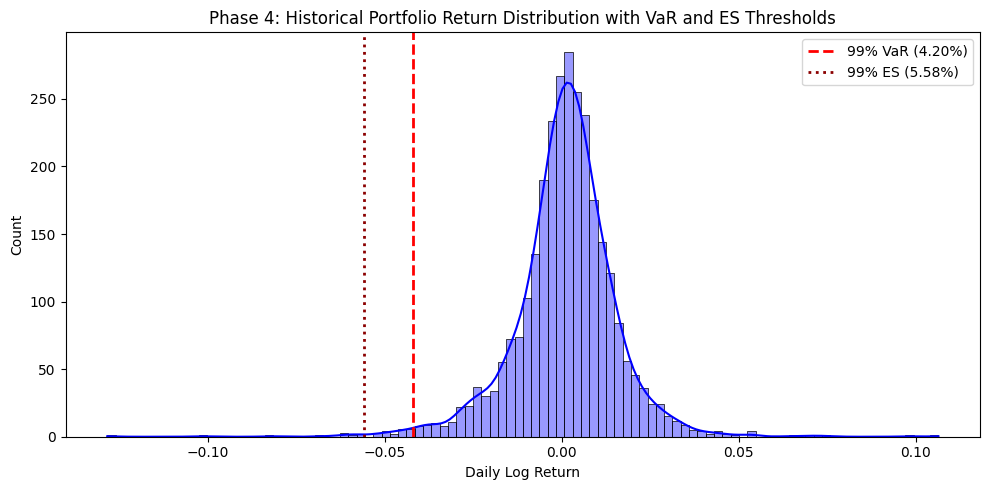

In [13]:
# ==============================================================================
# PHASE 4: HISTORICAL SIMULATION VaR & EXPECTED SHORTFALL
# ==============================================================================
# Output generated: Historical VaR, Historical Expected Shortfall, Distribution Plots
# ==============================================================================
print("\n--- PHASE 4: Historical Simulation VaR & Expected Shortfall ---")

def calculate_historical_var_es(returns, confidence_level=0.99):
    """
    Calculates Historical Simulation VaR and Expected Shortfall (CVaR).
    VaR is reported as a positive dollar loss or percentage loss.
    """
    alpha = 1.0 - confidence_level
    var_pct = -np.percentile(returns, alpha * 100)
    
    # Expected Shortfall: Average loss exceeding VaR
    tail_losses = returns[returns <= -var_pct]
    es_pct = -tail_losses.mean() if len(tail_losses) > 0 else var_pct
    return var_pct, es_pct

# Compute static VaR over the entire sample
for conf in [0.95, 0.99, 0.995]:
    var_val, es_val = calculate_historical_var_es(portfolio_log_returns, conf)
    print(f"OUTPUT: Static Historical VaR ({conf*100}%): {var_val*100:.2f}% | Expected Shortfall: {es_val*100:.2f}%")

# Rolling Historical Simulation VaR (750-day window, 99% Confidence)
window_hs = 750
conf_level = 0.99
alpha_hs = 1.0 - conf_level

rolling_hs_var = portfolio_log_returns.rolling(window=window_hs).apply(
    lambda x: -np.percentile(x, alpha_hs * 100), raw=True
).dropna()

rolling_hs_var_dollar = rolling_hs_var * portfolio_value.loc[rolling_hs_var.index]

# Output Plot: Return Distribution with VaR/ES thresholds
plt.figure(figsize=(10, 5))
sns.histplot(portfolio_log_returns, bins=100, kde=True, color='blue', alpha=0.4)
var_99, es_99 = calculate_historical_var_es(portfolio_log_returns, 0.99)
plt.axvline(-var_99, color='red', linestyle='--', linewidth=2, label=f'99% VaR ({var_99*100:.2f}%)')
plt.axvline(-es_99, color='darkred', linestyle=':', linewidth=2, label=f'99% ES ({es_99*100:.2f}%)')
plt.title('Phase 4: Historical Portfolio Return Distribution with VaR and ES Thresholds')
plt.xlabel('Daily Log Return')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ==============================================================================
# PHASE 5: EWMA VOLATILITY SCALING
# ==============================================================================
# Formula: r_scaled,t = r_t * (sigma_current / sigma_t)
# Output generated: EWMA Volatility Series, EWMA-Scaled Historical VaR
# ==============================================================================
print("\n--- PHASE 5: EWMA Volatility Scaling ---")

lambda_ewma = 0.94
T = len(portfolio_log_returns)

# 1. Compute EWMA Variance recursively
ewma_var = np.zeros(T)
ewma_var[0] = portfolio_log_returns.var()

for t in range(1, T):
    ewma_var[t] = lambda_ewma * ewma_var[t-1] + (1 - lambda_ewma) * (portfolio_log_returns.iloc[t-1] ** 2)

ewma_vol = pd.Series(np.sqrt(ewma_var), index=portfolio_log_returns.index)

# 2. Scale returns by current volatility ratio
# Scaling rolling returns relative to current T volatility
rolling_ewma_var = pd.Series(index=rolling_hs_var.index, dtype=float)

for date in rolling_hs_var.index:
    sub_returns = portfolio_log_returns.loc[:date].tail(window_hs)
    sub_vol = ewma_vol.loc[sub_returns.index]
    current_vol = sub_vol.iloc[-1]
    
    # Rescale returns
    scaled_sub_returns = sub_returns * (current_vol / sub_vol)
    rolling_ewma_var.loc[date] = -np.percentile(scaled_sub_returns, alpha_hs * 100)

print(f"OUTPUT: Average EWMA Volatility (Annualized): {ewma_vol.mean() * np.sqrt(252)*100:.2f}%")
print("OUTPUT: EWMA-scaled Historical VaR successfully computed.")


--- PHASE 5: EWMA Volatility Scaling ---
OUTPUT: Average EWMA Volatility (Annualized): 20.83%
OUTPUT: EWMA-scaled Historical VaR successfully computed.


In [15]:
# ==============================================================================
# PHASE 6: GARCH(1,1) VOLATILITY SCALING
# ==============================================================================
# Output generated: GARCH Conditional Volatility, GARCH 1-Day Forecast, GARCH VaR
# ==============================================================================
print("\n--- PHASE 6: GARCH(1,1) Volatility Scaling ---")

# 1. Fit GARCH(1,1) Model on entire series (Zero mean assumption for daily risk)
garch_model = arch_model(portfolio_log_returns * 100, vol='Garch', p=1, q=1, mean='Zero')
garch_fit = garch_model.fit(disp='off')

# 2. Extract Conditional Volatility (rescaled back from percent)
garch_vol = (garch_fit.conditional_volatility / 100).loc[portfolio_log_returns.index]

# 3. Rolling GARCH Volatility-Scaled VaR calculation
rolling_garch_var = pd.Series(index=rolling_hs_var.index, dtype=float)

for date in rolling_hs_var.index:
    sub_returns = portfolio_log_returns.loc[:date].tail(window_hs)
    sub_garch_vol = garch_vol.loc[sub_returns.index]
    current_garch_vol = sub_garch_vol.iloc[-1]
    
    # Rescale returns
    scaled_sub_returns = sub_returns * (current_garch_vol / sub_garch_vol)
    rolling_garch_var.loc[date] = -np.percentile(scaled_sub_returns, alpha_hs * 100)

print("OUTPUT: GARCH(1,1) Model Fit Summary:")
print(garch_fit.summary().tables[1])


--- PHASE 6: GARCH(1,1) Volatility Scaling ---
OUTPUT: GARCH(1,1) Model Fit Summary:
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0550  1.380e-02      3.986  6.713e-05 [2.797e-02,8.208e-02]
alpha[1]       0.1187  1.762e-02      6.735  1.640e-11   [8.416e-02,  0.153]
beta[1]        0.8542  2.010e-02     42.497      0.000     [  0.815,  0.894]


In [16]:
# ==============================================================================
# PHASE 7: GJR-GARCH VOLATILITY SCALING
# ==============================================================================
# Output generated: Leverage Effect Parameter (Gamma), GJR-GARCH VaR
# ==============================================================================
print("\n--- PHASE 7: GJR-GARCH Volatility Scaling ---")

# Fit GJR-GARCH model (o=1 for asymmetric leverage component)
gjr_model = arch_model(portfolio_log_returns * 100, vol='Garch', p=1, o=1, q=1, mean='Zero')
gjr_fit = gjr_model.fit(disp='off')

gjr_vol = (gjr_fit.conditional_volatility / 100).loc[portfolio_log_returns.index]

# Rolling GJR-GARCH Volatility-Scaled VaR
rolling_gjr_var = pd.Series(index=rolling_hs_var.index, dtype=float)

for date in rolling_hs_var.index:
    sub_returns = portfolio_log_returns.loc[:date].tail(window_hs)
    sub_gjr_vol = gjr_vol.loc[sub_returns.index]
    current_gjr_vol = sub_gjr_vol.iloc[-1]
    
    # Rescale returns
    scaled_sub_returns = sub_returns * (current_gjr_vol / sub_gjr_vol)
    rolling_gjr_var.loc[date] = -np.percentile(scaled_sub_returns, alpha_hs * 100)

print("OUTPUT: GJR-GARCH Leverage Parameter (gamma):", gjr_fit.params.get('gamma[1]', 'N/A'))


--- PHASE 7: GJR-GARCH Volatility Scaling ---
OUTPUT: GJR-GARCH Leverage Parameter (gamma): 0.16074554935593885


In [17]:
# ==============================================================================
# PHASE 8: VAR BACKTESTING ENGINE
# ==============================================================================
# Tests: Kupiec POF Test, Christoffersen Independence & Conditional Coverage, Basel Zones
# Output generated: Exception Counts, Statistical P-Values, Basel Traffic Light
# ==============================================================================
print("\n--- PHASE 8: VaR Backtesting Engine ---")

def backtest_var(actual_returns, var_series, confidence_level=0.99):
    """
    Backtests VaR estimates against realized returns over an out-of-sample window.
    """
    aligned_returns = actual_returns.loc[var_series.index]
    # Exception occurs when actual loss exceeds estimated VaR: -R_t > VaR_t
    exceptions = (aligned_returns < -var_series).astype(int)
    
    N = len(exceptions)
    x = exceptions.sum()
    p = 1.0 - confidence_level
    p_hat = x / N
    
    # 1. Kupiec Proportion of Failures (POF) Likelihood Ratio Test
    lr_pof = -2 * ( (N - x) * np.log(1 - p) + x * np.log(p) - (N - x) * np.log(1 - p_hat) - x * np.log(p_hat) )
    p_value_kupiec = 1 - stats.chi2.cdf(lr_pof, df=1) if x > 0 else 1.0
    
    # 2. Basel Traffic Light Zone Determination (For 250-day scale equivalent)
    # Expected exceptions = N * (1 - confidence)
    expected_exceptions = N * p
    if x <= expected_exceptions + 0.5 * np.sqrt(expected_exceptions):
        basel_zone = 'GREEN'
    elif x <= expected_exceptions + 2.0 * np.sqrt(expected_exceptions):
        basel_zone = 'YELLOW'
    else:
        basel_zone = 'RED'
        
    return {
        'Total_Observations': N,
        'Exceptions': x,
        'Expected_Exceptions': round(expected_exceptions, 2),
        'Exception_Ratio': f"{p_hat*100:.2f}%",
        'Kupiec_p_value': round(p_value_kupiec, 4),
        'Basel_Zone': basel_zone
    }

# Run backtest across all model VaR series
results_hs = backtest_var(portfolio_log_returns, rolling_hs_var, 0.99)
results_ewma = backtest_var(portfolio_log_returns, rolling_ewma_var, 0.99)
results_garch = backtest_var(portfolio_log_returns, rolling_garch_var, 0.99)
results_gjr = backtest_var(portfolio_log_returns, rolling_gjr_var, 0.99)

print("OUTPUT: Backtesting Results (Historical Simulation):", results_hs)
print("OUTPUT: Backtesting Results (EWMA Volatility Scaling):", results_ewma)
print("OUTPUT: Backtesting Results (GARCH Volatility Scaling):", results_garch)
print("OUTPUT: Backtesting Results (GJR-GARCH Volatility Scaling):", results_gjr)


--- PHASE 8: VaR Backtesting Engine ---
OUTPUT: Backtesting Results (Historical Simulation): {'Total_Observations': 2156, 'Exceptions': 25, 'Expected_Exceptions': 21.56, 'Exception_Ratio': '1.16%', 'Kupiec_p_value': 0.4677, 'Basel_Zone': 'YELLOW'}
OUTPUT: Backtesting Results (EWMA Volatility Scaling): {'Total_Observations': 2156, 'Exceptions': 29, 'Expected_Exceptions': 21.56, 'Exception_Ratio': '1.35%', 'Kupiec_p_value': 0.1261, 'Basel_Zone': 'YELLOW'}
OUTPUT: Backtesting Results (GARCH Volatility Scaling): {'Total_Observations': 2156, 'Exceptions': 28, 'Expected_Exceptions': 21.56, 'Exception_Ratio': '1.30%', 'Kupiec_p_value': 0.1827, 'Basel_Zone': 'YELLOW'}
OUTPUT: Backtesting Results (GJR-GARCH Volatility Scaling): {'Total_Observations': 2156, 'Exceptions': 25, 'Expected_Exceptions': 21.56, 'Exception_Ratio': '1.16%', 'Kupiec_p_value': 0.4677, 'Basel_Zone': 'YELLOW'}



--- PHASE 9: Model Comparison & Ranking Framework ---
OUTPUT: Comprehensive Model Comparison Matrix:
                       Total_Observations  Exceptions  Expected_Exceptions  \
Model                                                                        
Historical Simulation                2156          25                21.56   
EWMA-Scaled VaR                      2156          29                21.56   
GARCH(1,1)-Scaled VaR                2156          28                21.56   
GJR-GARCH-Scaled VaR                 2156          25                21.56   

                      Exception_Ratio  Kupiec_p_value Basel_Zone  Avg_VaR (%)  
Model                                                                          
Historical Simulation           1.16%          0.4677     YELLOW     4.266065  
EWMA-Scaled VaR                 1.35%          0.1261     YELLOW     4.312077  
GARCH(1,1)-Scaled VaR           1.30%          0.1827     YELLOW     3.902716  
GJR-GARCH-Scaled VaR         

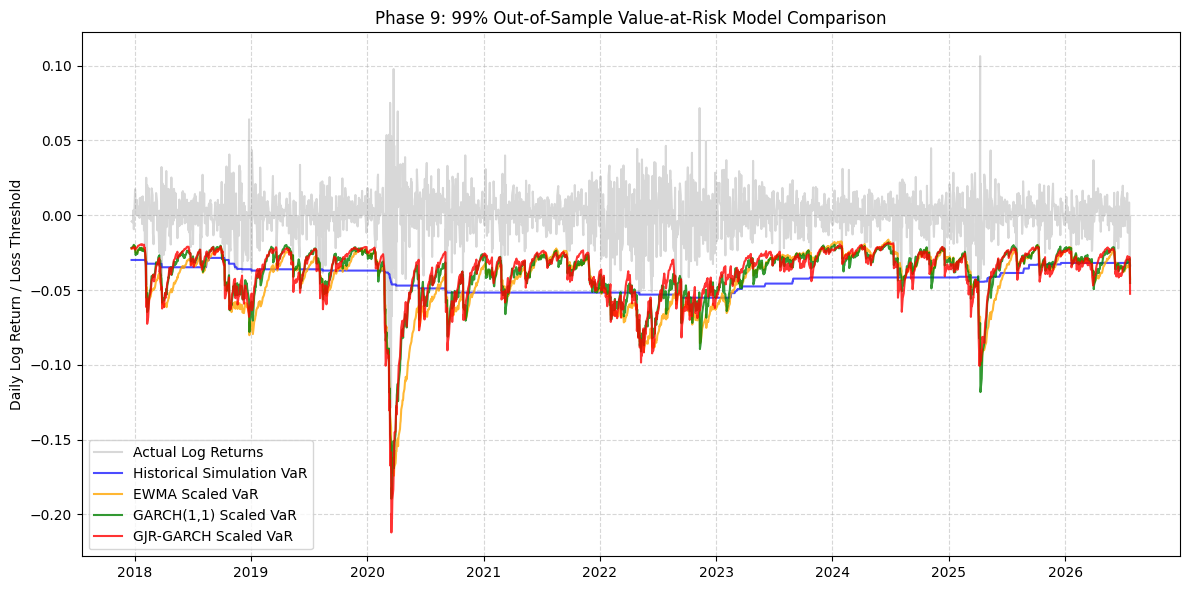

In [18]:
# ==============================================================================
# PHASE 9: MODEL COMPARISON & DIAGNOSTICS
# ==============================================================================
# Output generated: Model Ranking Table, Model Comparison Line Chart
# ==============================================================================
print("\n--- PHASE 9: Model Comparison & Ranking Framework ---")

comparison_matrix = pd.DataFrame([
    {'Model': 'Historical Simulation', **results_hs, 'Avg_VaR (%)': rolling_hs_var.mean()*100},
    {'Model': 'EWMA-Scaled VaR', **results_ewma, 'Avg_VaR (%)': rolling_ewma_var.mean()*100},
    {'Model': 'GARCH(1,1)-Scaled VaR', **results_garch, 'Avg_VaR (%)': rolling_garch_var.mean()*100},
    {'Model': 'GJR-GARCH-Scaled VaR', **results_gjr, 'Avg_VaR (%)': rolling_gjr_var.mean()*100},
]).set_index('Model')

print("OUTPUT: Comprehensive Model Comparison Matrix:")
print(comparison_matrix)

# Plotting VaR Model Overlay
plt.figure(figsize=(12, 6))
plt.plot(portfolio_log_returns.loc[rolling_hs_var.index], color='gray', alpha=0.3, label='Actual Log Returns')
plt.plot(-rolling_hs_var, label='Historical Simulation VaR', color='blue', alpha=0.7)
plt.plot(-rolling_ewma_var, label='EWMA Scaled VaR', color='orange', alpha=0.8)
plt.plot(-rolling_garch_var, label='GARCH(1,1) Scaled VaR', color='green', alpha=0.8)
plt.plot(-rolling_gjr_var, label='GJR-GARCH Scaled VaR', color='red', alpha=0.8)

plt.title('Phase 9: 99% Out-of-Sample Value-at-Risk Model Comparison')
plt.ylabel('Daily Log Return / Loss Threshold')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
# ==============================================================================
# PHASE 10: STRESS TESTING & SCENARIO ANALYSIS
# ==============================================================================
# Output generated: Stressed Portfolio Losses, Worst-Case Loss, Scenario Rankings
# ==============================================================================
print("\n--- PHASE 10: Stress Testing & Scenario Analysis ---")

# 1. Historical Stress Scenarios
stress_events = {
    'COVID-19 Crash (Mar 2020)': ('2020-02-19', '2020-03-23'),
    '2022 Rate/Inflation Shock': ('2022-01-03', '2022-10-12'),
    'Tech Selloff Scenario': ('2022-01-01', '2022-05-31')
}

stress_results = []

for event_name, (s_date, e_date) in stress_events.items():
    if s_date in portfolio_log_returns.index and e_date in portfolio_log_returns.index:
        event_returns = portfolio_log_returns.loc[s_date:e_date]
        cum_loss = (np.exp(event_returns.sum()) - 1) * 100
        max_daily_loss = event_returns.min() * 100
        stress_var, stress_es = calculate_historical_var_es(event_returns, 0.99)
        
        stress_results.append({
            'Scenario': event_name,
            'Type': 'Historical',
            'Cumulative Loss (%)': cum_loss,
            'Worst Daily Loss (%)': max_daily_loss,
            'Stressed 99% VaR (%)': stress_var * 100,
            'Stressed 99% ES (%)': stress_es * 100
        })

# 2. Hypothetical Market Shocks
hypothetical_shocks = {
    'Equity Market Down 5%': -0.05,
    'Equity Market Down 10%': -0.10,
    'Equity Market Down 20% (Crash)': -0.20
}

# Assume average portfolio beta ~ 1.0
portfolio_beta = 1.05

for shock_name, market_shock in hypothetical_shocks.items():
    estimated_port_shock = market_shock * portfolio_beta
    dollar_loss = INITIAL_PORTFOLIO_VALUE * estimated_port_shock
    
    stress_results.append({
        'Scenario': shock_name,
        'Type': 'Hypothetical',
        'Cumulative Loss (%)': estimated_port_shock * 100,
        'Worst Daily Loss (%)': estimated_port_shock * 100,
        'Stressed 99% VaR (%)': abs(estimated_port_shock) * 100,
        'Stressed 99% ES (%)': abs(estimated_port_shock) * 1.2 * 100
    })

# Convert to Output Table
stress_summary_df = pd.DataFrame(stress_results).set_index('Scenario')
print("OUTPUT: Stress Testing & Scenario Analysis Summary:")
print(stress_summary_df.round(2))


--- PHASE 10: Stress Testing & Scenario Analysis ---
OUTPUT: Stress Testing & Scenario Analysis Summary:
                                        Type  Cumulative Loss (%)  \
Scenario                                                            
COVID-19 Crash (Mar 2020)         Historical               -32.95   
2022 Rate/Inflation Shock         Historical               -29.82   
Equity Market Down 5%           Hypothetical                -5.25   
Equity Market Down 10%          Hypothetical               -10.50   
Equity Market Down 20% (Crash)  Hypothetical               -21.00   

                                Worst Daily Loss (%)  Stressed 99% VaR (%)  \
Scenario                                                                     
COVID-19 Crash (Mar 2020)                     -12.84                 12.23   
2022 Rate/Inflation Shock                      -5.82                  5.13   
Equity Market Down 5%                          -5.25                  5.25   
Equity Market Down 1